# Name : Prajwal Kola
# Roll no : 33
# Expt.-8: Clustering of Countries with World Bank API

# Part 1

In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

In [3]:
def fetch_indicator(code, year="2022"):
  url = f"https://api.worldbank.org/v2/country/all/indicator/{code}?date={year}&format=json&per_page=30000"
  response = requests.get(url).json()[1]

  data ={}
  for item in response:
    country = item["country"]["value"]
    value = item["value"]
    if value is not None:
      data[country] = value
  return pd.Serirs(data, name=code)

In [6]:
def fetch_indicator(code, year="2022"):
  url = f"https://api.worldbank.org/v2/country/all/indicator/{code}?date={year}&format=json&per_page=30000"
  response = requests.get(url).json()[1]

  data ={}
  for item in response:
    country = item["country"]["value"]
    value = item["value"]
    if value is not None:
      data[country] = value
  return pd.Series(data, name=code)

gdp = fetch_indicator("NY.GDP.PCAP.CD")
pop = fetch_indicator("SP.POP.TOTL")
life = fetch_indicator("SP.DYN.LE00.IN")
lit = fetch_indicator("SE.ADT.LITR.ZS")

In [8]:
df=pd.concat([gdp,pop,life,lit],axis=1)
df.columns=['GDP','Population','Life Expectancy','Literacy']
df.dropna(inplace=True)
df.head()

,GDP,Population,Life Expectancy,Literacy
Africa Eastern and Southern,1679.327622,731821393,64.487020,73.055977
Africa Western and Central,2138.473153,497387180,57.987813,60.780979
Arab World,7950.355820,471352066,71.876096,78.271927
Central Europe and the Baltics,19530.155323,100071871,76.652299,99.479919
Early-demographic dividend,4043.827763,3470644834,71.430455,81.242798


In [9]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)

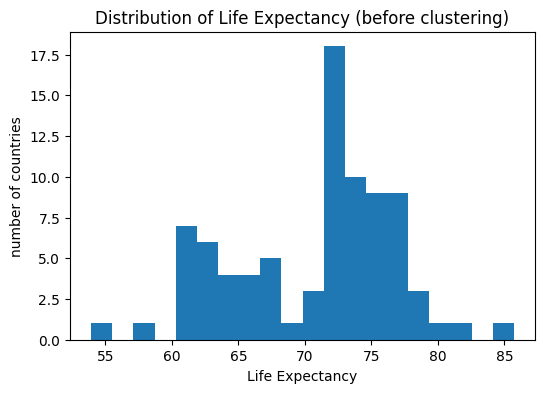

In [11]:
plt.figure(figsize=(6,4))
plt.hist(df["Life Expectancy"],bins=20)
plt.xlabel("Life Expectancy")
plt.ylabel("number of countries")
plt.title("Distribution of Life Expectancy (before clustering)")
plt.show()

# Part 2

k	wcss
1 	 336.00000000000006
2 	 206.43717192603808
3 	 142.06028324967596
4 	 122.46400641421171
5 	 68.71234707726028
6 	 56.092718405819106
7 	 51.08265517326418
8 	 41.70851027024395
9 	 31.213863029560223
10 	 27.04725098650771


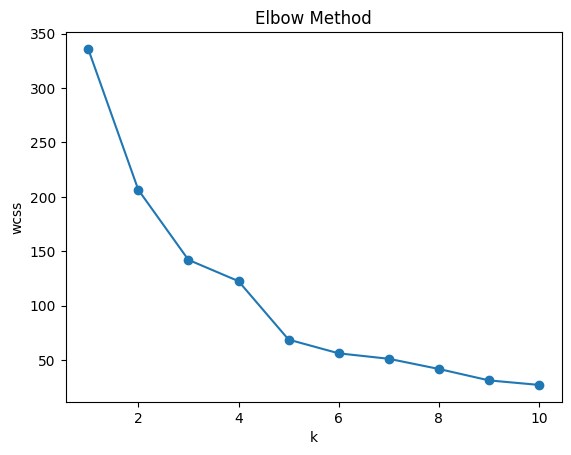

In [14]:
wcss = []
for k in range(1,11):
  km = KMeans(n_clusters=k, random_state=0)
  km.fit(x_scaled)
  wcss.append(km.inertia_)

print("k\twcss")
for i in range(10):
  print(i+1, "\t", wcss[i])

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("k")
plt.ylabel("wcss")
plt.title("Elbow Method")
plt.show()

# Part : clustering algo

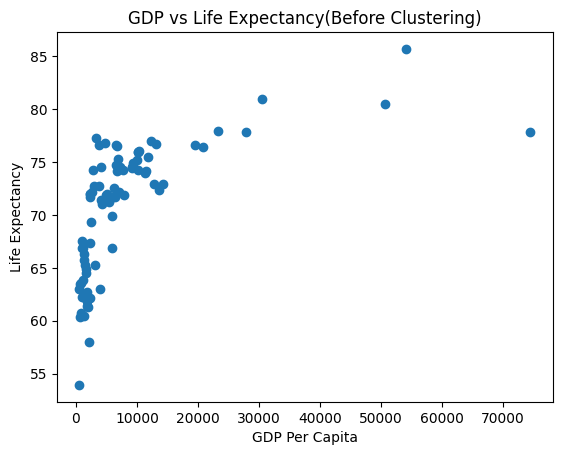

In [23]:
plt.scatter(df["GDP"],df["Life Expectancy"])
plt.xlabel("GDP Per Capita")
plt.ylabel("Life Expectancy")
plt.title("GDP vs Life Expectancy(Before Clustering)")
plt.show()

In [18]:
kMeans = KMeans(n_clusters=3, random_state=0)

labels_km = kMeans.fit_predict(x_scaled)

df["kMeans_labels"] = labels_km

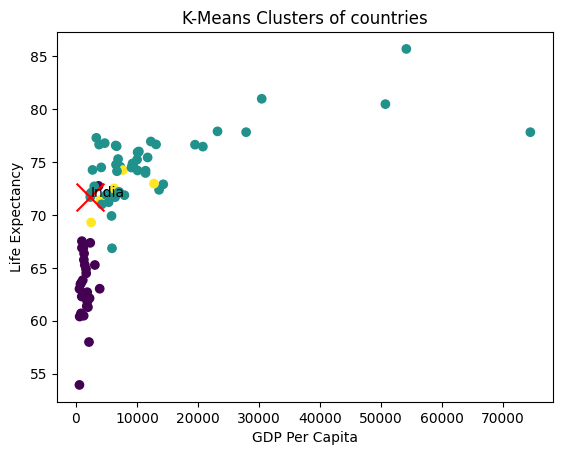

In [43]:
plt.scatter(df["GDP"],df["Life Expectancy"], c=labels_km)
plt.xlabel("GDP Per Capita")
plt.ylabel("Life Expectancy")
plt.title("K-Means Clusters of countries")
india = df.loc["India"]
plt.scatter(india["GDP"], india["Life Expectancy"], s=400, color='red', marker='x')
plt.text(india["GDP"], india["Life Expectancy"], "India")
plt.show()

In [ ]:
hc = AgglomerativeClustering(n_clusters=3)
labels_hc = hc.fit_predict(x_scaled)

df["hierarchical_labels"] = labels_hc

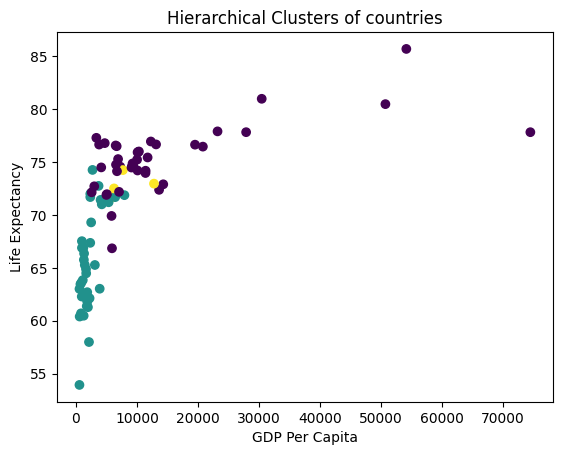

In [30]:
plt.scatter(df["GDP"],df["Life Expectancy"], c=labels_hc)
plt.xlabel("GDP Per Capita")
plt.ylabel("Life Expectancy")
plt.title("Hierarchical Clusters of countries")
plt.show()

In [32]:
cluster_summary = df.groupby("kMeans_labels")[["GDP","Population","Life Expectancy","Literacy"]].mean()
print(cluster_summary)

                        GDP    Population  Life Expectancy   Literacy
kMeans_labels                                                        
0               1601.971896  4.854521e+08        63.478867  66.779721
1              12288.225626  4.669122e+08        74.753258  92.910908
2               6437.349751  5.501554e+09        71.975830  84.851687


In [35]:
country_name = "India"
result = df.loc[country_name]

print("Country:", country_name)
print("GDP Per Capita:", result["GDP"])
print("Life Expectancy:", result["Life Expectancy"])
print("Lteracy rate:", result["Literacy"])
print("Population:", result["Population"])
print("K-means Cluster:", result["kMeans_labels"])
print("Hierarchical Cluster:", result["hierarchical_labels"])

Country: India
GDP Per Capita: 2347.44829434623
Life Expectancy: 71.698
Lteracy rate: 76.3199996948242
Population: 1425423212.0
K-means Cluster: 1.0
Hierarchical Cluster: 1.0


In [36]:
country_name = "North America"
result = df.loc[country_name]

print("Country:", country_name)
print("GDP Per Capita:", result["GDP"])
print("Life Expectancy:", result["Life Expectancy"])
print("Lteracy rate:", result["Literacy"])
print("Population:", result["Population"])
print("K-means Cluster:", result["kMeans_labels"])
print("Hierarchical Cluster:", result["hierarchical_labels"])

Country: North America
GDP Per Capita: 74535.6365392629
Life Expectancy: 77.8327679594239
Lteracy rate: 98.7891464233398
Population: 373018004.0
K-means Cluster: 1.0
Hierarchical Cluster: 0.0


In [37]:
country_name = "Brazil"
result = df.loc[country_name]

print("Country:", country_name)
print("GDP Per Capita:", result["GDP"])
print("Life Expectancy:", result["Life Expectancy"])
print("Lteracy rate:", result["Literacy"])
print("Population:", result["Population"])
print("K-means Cluster:", result["kMeans_labels"])
print("Hierarchical Cluster:", result["hierarchical_labels"])

Country: Brazil
GDP Per Capita: 9281.33282136864
Life Expectancy: 74.872
Lteracy rate: 94.3853874531348
Population: 210306415.0
K-means Cluster: 1.0
Hierarchical Cluster: 0.0


In [38]:
country_name = "Viet Nam"
result = df.loc[country_name]

print("Country:", country_name)
print("GDP Per Capita:", result["GDP"])
print("Life Expectancy:", result["Life Expectancy"])
print("Lteracy rate:", result["Literacy"])
print("Population:", result["Population"])
print("K-means Cluster:", result["kMeans_labels"])
print("Hierarchical Cluster:", result["hierarchical_labels"])

Country: Viet Nam
GDP Per Capita: 4147.69777213621
Life Expectancy: 74.502
Lteracy rate: 96.129997253418
Population: 99680655.0
K-means Cluster: 1.0
Hierarchical Cluster: 0.0


In [39]:
country_name = "Bahrain"
result = df.loc[country_name]

print("Country:", country_name)
print("GDP Per Capita:", result["GDP"])
print("Life Expectancy:", result["Life Expectancy"])
print("Lteracy rate:", result["Literacy"])
print("Population:", result["Population"])
print("K-means Cluster:", result["kMeans_labels"])
print("Hierarchical Cluster:", result["hierarchical_labels"])

Country: Bahrain
GDP Per Capita: 30470.5219276023
Life Expectancy: 80.992
Lteracy rate: 97.870002746582
Population: 1524693.0
K-means Cluster: 1.0
Hierarchical Cluster: 0.0
